# Design Variable Selection

We started by discretionarily selecting the following 7 design variables to use to predict our target variables (total waste and total impurities, 2 key manufacturing outcomes in the pharaceutical drug design process): tbl_fill_mean, cyl_height_mean, startup_tbl_fill_maxDifference, startup_tbl_fill_mean, main_compForce_mean, main_compForce_sd, and ejection_mean.

Before building a deep neural network with strong predictive performance we want to add more design variables to improve our model capacity. In this section, we will go through the data collected in Process.csv to extract meaningful design variables beyond the original 7 that we discretionarily selected via domain knowledge. 

This workflow used below employs a combined statistical and model-based feature-selection pipeline that identifies the key process design variables most strongly influencing the manufacturing quality targets total waste and total impurities.

In [38]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance

import seaborn as sns
import matplotlib.pyplot as plt

# Normalization of batch-dependent variables

In [39]:
#Normalize batch-dependent variables
normalization = pd.read_csv("data/Normalization.csv", delimiter=";")
process_full = pd.read_csv("data/Process.csv", delimiter=";")

print("Full process shape:", process_full.shape)
print("Columns:", list(process_full.columns))


process = process_full.merge(
    normalization[['Product code', 'Normalisation factor']],
    how='left',
    left_on='code',
    right_on='Product code')

batch_dependent_vars = [
    'total_waste',
    'tbl_speed_0_duration',
    'tbl_speed_change',
    'tbl_fill_mean',
    'cyl_height_mean',
    'Startup_tbl_fill_maxDifference',
    'Startup_tbl_fill_mean',
    'startup_waste',
    'fom_change']

for var in batch_dependent_vars:
    if var in process.columns:
        process[var] = process[var] / process['Normalisation factor']

Full process shape: (1005, 35)
Columns: ['batch', 'code', 'tbl_speed_mean', 'tbl_speed_change', 'tbl_speed_0_duration', 'total_waste', 'startup_waste', 'weekend', 'fom_mean', 'fom_change', 'SREL_startup_mean', 'SREL_production_mean', 'SREL_production_max', 'main_CompForce mean', 'main_CompForce_sd', 'main_CompForce_median', 'pre_CompForce_mean', 'tbl_fill_mean', 'tbl_fill_sd', 'cyl_height_mean', 'stiffness_mean', 'stiffness_max', 'stiffness_min', 'ejection_mean', 'ejection_max', 'ejection_min', 'Startup_tbl_fill_maxDifference', 'Startup_main_CompForce_mean', 'Startup_tbl_fill_mean', 'Drug release average (%)', 'Drug release min (%)', 'Residual solvent', 'Total impurities', 'Impurity O', 'Impurity L']


# Drop Variable Candidates

In [40]:
#Drop variables that will not be featurized (redundant, non-integer)

cols_to_drop = ['batch', 'code', 'Product code', 'Normalisation factor', 'weekend']

#Remove max and min values for variables that already have mean values in the dataset
cols_to_drop.append('ejection_max')
cols_to_drop.append('ejection_min')
cols_to_drop.append('stiffness_max')
cols_to_drop.append('stiffness_min')
cols_to_drop.append('SREL_production_max')

#Remove variables that are part of total waste or total impurities that can cause data leakage
cols_to_drop.append('startup_waste')

process = process.drop(columns=[c for c in cols_to_drop if c in process.columns])

print("After merge + normalization + drop IDs:", process.shape)

#Drop rows with missing values
process = process.dropna()
print("After dropna:", process.shape)

After merge + normalization + drop IDs: (1005, 26)
After dropna: (987, 26)


# Isolate Design Variable Candidates

In [41]:
#Define targets and design variables (ALL other process vars)
#Targets: Total impurities, total_waste
# We EXCLUDE QC outcome variables from features to avoid leakage

target_vars = ['Total impurities', 'total_waste']

# QC / outcome variables you probably do NOT want as predictors
qc_vars = [
    'Drug release average (%)',
    'Drug release min (%)',
    'Residual solvent',
    'Impurity O',
    'Impurity L']

non_feature_cols = target_vars + qc_vars

design_vars = [c for c in process.columns if c not in non_feature_cols]
print("Number of design vars (all other process features):", len(design_vars))
print("Design vars:", design_vars)

Number of design vars (all other process features): 19
Design vars: ['tbl_speed_mean', 'tbl_speed_change', 'tbl_speed_0_duration', 'fom_mean', 'fom_change', 'SREL_startup_mean', 'SREL_production_mean', 'main_CompForce mean', 'main_CompForce_sd', 'main_CompForce_median', 'pre_CompForce_mean', 'tbl_fill_mean', 'tbl_fill_sd', 'cyl_height_mean', 'stiffness_mean', 'ejection_mean', 'Startup_tbl_fill_maxDifference', 'Startup_main_CompForce_mean', 'Startup_tbl_fill_mean']


# DBSCAN to Eliminate Outliers in Dataset

Best eps: 1.8, Best min_samples: 20, Best silhouette: 0.158


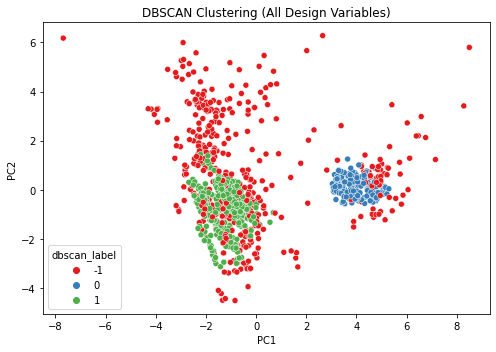

In [42]:
#Scale design variables

X = process[design_vars]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#DBSCAN hyperparameter tuning on the EXPANDED feature space

eps_values = [0.5, 0.8, 1.0, 1.2, 1.5, 1.8]
min_samples_values = [5, 10, 14, 20, 25]

best_eps, best_min_samples, best_silhouette = 0, 0, -1

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        # Valid clustering: at least 2 clusters and not every point in own cluster
        if len(set(labels)) > 1 and len(set(labels)) != len(X):
            silhouette_avg = silhouette_score(X_scaled, labels)
            if silhouette_avg > best_silhouette:
                best_silhouette = silhouette_avg
                best_eps = eps
                best_min_samples = min_samples

print(f"Best eps: {best_eps}, Best min_samples: {best_min_samples}, "
      f"Best silhouette: {best_silhouette:.3f}")

#Train DBSCAN with best hyperparameters and attach labels

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels = dbscan.fit_predict(X_scaled)
process['dbscan_label'] = labels

#Visualize clusters in PCA space (first 2 PCs of expanded space)

pca_2d = PCA(n_components=2)
PCs_2d = pca_2d.fit_transform(X_scaled)
process['PC1'] = PCs_2d[:, 0]
process['PC2'] = PCs_2d[:, 1]

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=process,
    x='PC1',
    y='PC2',
    hue='dbscan_label',
    palette='Set1')
plt.title("DBSCAN Clustering (All Design Variables)")
plt.tight_layout()
plt.show()

In [43]:
print(len(design_vars))   # number of features you think you have
print(X.shape)            # should be (n_samples, len(design_vars))
print(process.shape)      # after adding dbscan_label, PC1, PC2
print(process['dbscan_label'].value_counts())
print(design_vars)

19
(987, 19)
(987, 29)
-1    453
 1    388
 0    146
Name: dbscan_label, dtype: int64
['tbl_speed_mean', 'tbl_speed_change', 'tbl_speed_0_duration', 'fom_mean', 'fom_change', 'SREL_startup_mean', 'SREL_production_mean', 'main_CompForce mean', 'main_CompForce_sd', 'main_CompForce_median', 'pre_CompForce_mean', 'tbl_fill_mean', 'tbl_fill_sd', 'cyl_height_mean', 'stiffness_mean', 'ejection_mean', 'Startup_tbl_fill_maxDifference', 'Startup_main_CompForce_mean', 'Startup_tbl_fill_mean']


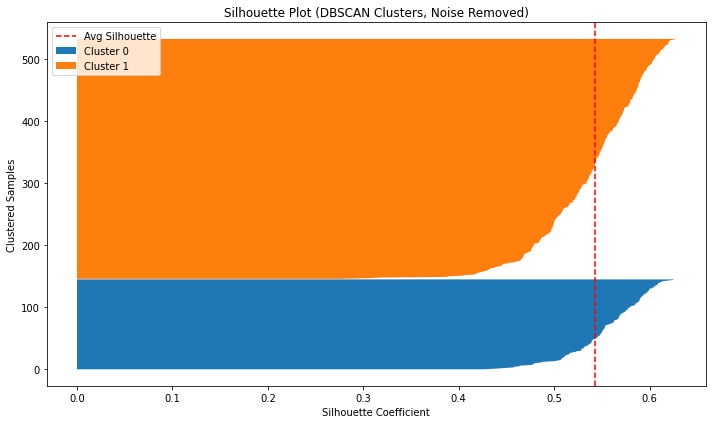

In [44]:
#Silhouette plot

from sklearn.metrics import silhouette_samples

mask = process['dbscan_label'] != -1
X_scaled_clean = X_scaled[mask]
labels_clean = process.loc[mask, 'dbscan_label'].values

silhouette_vals = silhouette_samples(X_scaled_clean, labels_clean)

process_clean = process[mask].reset_index(drop=True)
process_clean['silhouette'] = silhouette_vals

cluster_labels = sorted(np.unique(labels_clean))
y_lower = 0

plt.figure(figsize=(10, 6))

for label in cluster_labels:
    label_silhouette = process_clean[
        process_clean['dbscan_label'] == label
    ]['silhouette'].values
    label_silhouette.sort()

    size = len(label_silhouette)
    y_upper = y_lower + size

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        label_silhouette,
        label=f"Cluster {label}")
    y_lower = y_upper

plt.axvline(
    x=np.mean(silhouette_vals),
    color="red",
    linestyle="--",
    label="Avg Silhouette")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Clustered Samples")
plt.title("Silhouette Plot (DBSCAN Clusters, Noise Removed)")
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
#Drop clustering columns, keep only clean data

process = process_clean.drop(columns=['dbscan_label', 'PC1', 'PC2', 'silhouette'])
print("After DBSCAN noise removal:", process.shape)

X = process[design_vars]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled clean data:", X_scaled.shape)


After DBSCAN noise removal: (534, 26)
Scaled clean data: (534, 19)


# Correlation-driven Feature Distillation

In [46]:
corr_target_waste = process.corr()['total_waste'].sort_values(ascending=False)
corr_target_imp = process.corr()['Total impurities'].sort_values(ascending=False)

print(corr_target_waste)
print(corr_target_imp)

total_waste                       1.000000
tbl_speed_change                  0.833079
fom_change                        0.813303
tbl_fill_mean                     0.791032
tbl_speed_0_duration              0.789681
Startup_tbl_fill_mean             0.786830
cyl_height_mean                   0.782760
Startup_tbl_fill_maxDifference    0.406725
Drug release min (%)              0.333330
Drug release average (%)          0.326933
Residual solvent                  0.093470
Impurity L                        0.051643
SREL_startup_mean                 0.010411
SREL_production_mean              0.009934
tbl_fill_sd                      -0.002763
pre_CompForce_mean               -0.118792
Impurity O                       -0.120594
Total impurities                 -0.169680
main_CompForce_sd                -0.239086
stiffness_mean                   -0.244032
ejection_mean                    -0.389448
Startup_main_CompForce_mean      -0.439500
main_CompForce_median            -0.443263
main_CompFo

In [47]:
features = ['tbl_speed_change', 'fom_change', 'tbl_fill_mean', 'tbl_speed_0_duration', 'Startup_tbl_fill_mean',
            'cyl_height_mean', 'Startup_tbl_fill_maxDifference', 'Drug release min (%)', 'Drug release average (%)', 
           'fom_mean', 'main_CompForce_sd', 'ejection_mean', 'tbl_fill_sd', 'main_CompForce mean']
X = process[features].copy()

target_tw = 'total_waste'
target_ti = 'Total impurities'

# Perform XGB and Random Forest to Predict Target Variables

In [48]:
#Train RF + XGB and report R^2

def train_models(X_train, X_test, y_train, y_test, label=""):
    #Random Forest
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_r2 = r2_score(y_test, y_pred_rf)

    #XGBoost
    xgb = XGBRegressor(
        objective='reg:squarederror',
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        colsample_bytree=1.0,
        subsample=1.0,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1)
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    xgb_r2 = r2_score(y_test, y_pred_xgb)

    print(f"Random Forest R^2: {rf_r2:.4f}")
    print(f"XGBoost R^2: {xgb_r2:.4f}")

    return rf, xgb

In [49]:
def plot_global_importance(model, X_test, y_test, feature_names, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    #Tree-based feature_importances
    imp = model.feature_importances_
    idx = np.argsort(imp)
    axes[0].barh(np.array(feature_names)[idx], imp[idx])
    axes[0].set_title(f"{title} – Feature Importance")
    axes[0].set_xlabel("Importance")

    #Permutation importance
    perm = permutation_importance(
        model, X_test, y_test,
        n_repeats=20,
        random_state=42,
        n_jobs=-1)
    p_imp = perm.importances_mean
    idx2 = np.argsort(p_imp)
    axes[1].barh(np.array(feature_names)[idx2], p_imp[idx2])
    axes[1].set_title(f"{title} – Permutation Importance")
    axes[1].set_xlabel("Mean ΔR² when permuted")

    plt.tight_layout()
    plt.show()

In [50]:
def shap_beeswarm(model, X_test, title=""):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test)
    print(f"\nSHAP beeswarm for {title}")
    shap.plots.beeswarm(shap_values)

# Quantify Global and Local Feature Importance to Select Design Variables for Deep Learning Network

Random Forest R^2: 0.6439
XGBoost R^2: 0.6919


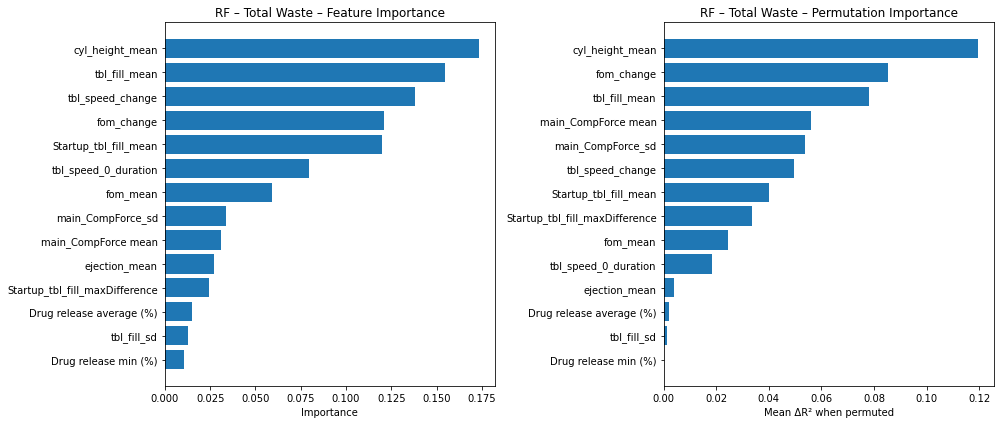

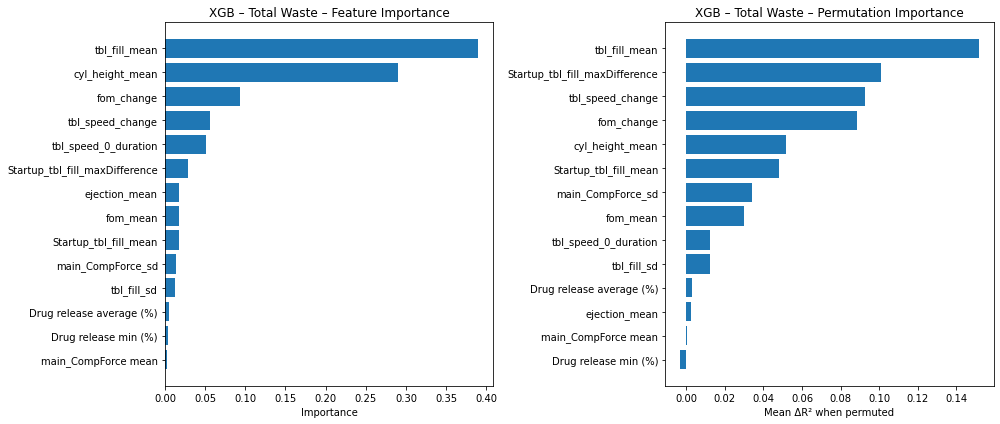


SHAP beeswarm for RF – Total Waste


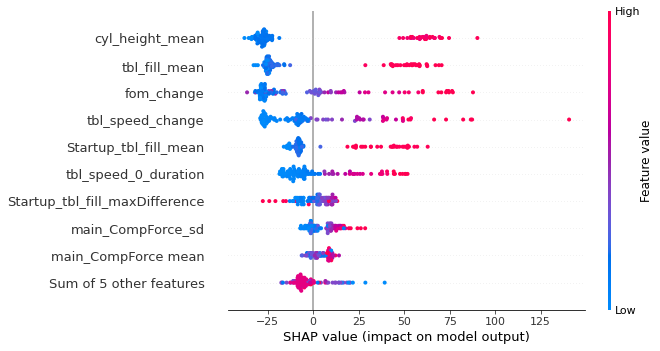

ntree_limit is deprecated, use `iteration_range` or model slicing instead.



SHAP beeswarm for XGB – Total Waste


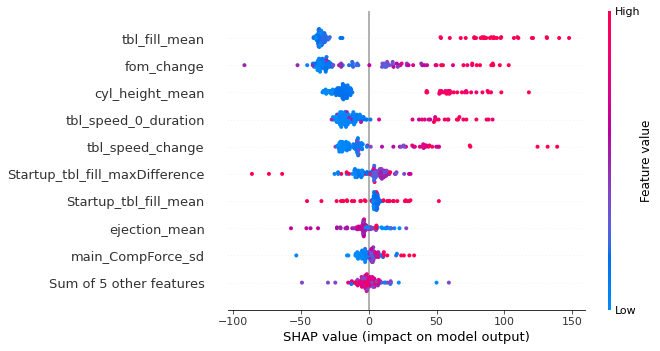

In [51]:
from sklearn.model_selection import train_test_split

#Total waste modeling
y_tw = process[target_tw].copy()

X_train_tw, X_test_tw, y_train_tw, y_test_tw = train_test_split(
    X, y_tw, test_size=0.2, random_state=42)

rf_tw, xgb_tw = train_models(
    X_train_tw, X_test_tw, y_train_tw, y_test_tw,
    label="Total Waste")

plot_global_importance(rf_tw, X_test_tw, y_test_tw, features, "RF – Total Waste")
plot_global_importance(xgb_tw, X_test_tw, y_test_tw, features, "XGB – Total Waste")

shap_beeswarm(rf_tw, X_test_tw, "RF – Total Waste")
shap_beeswarm(xgb_tw, X_test_tw, "XGB – Total Waste")

Random Forest R^2: 0.5801
XGBoost R^2: 0.4505


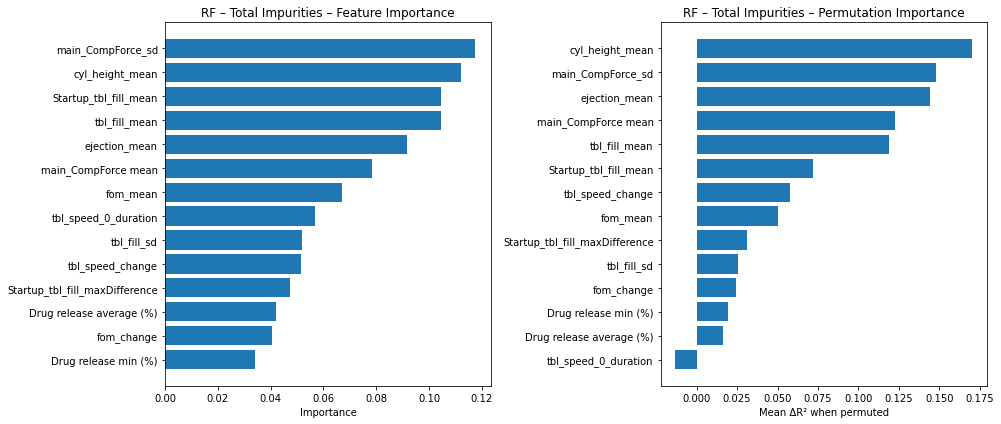

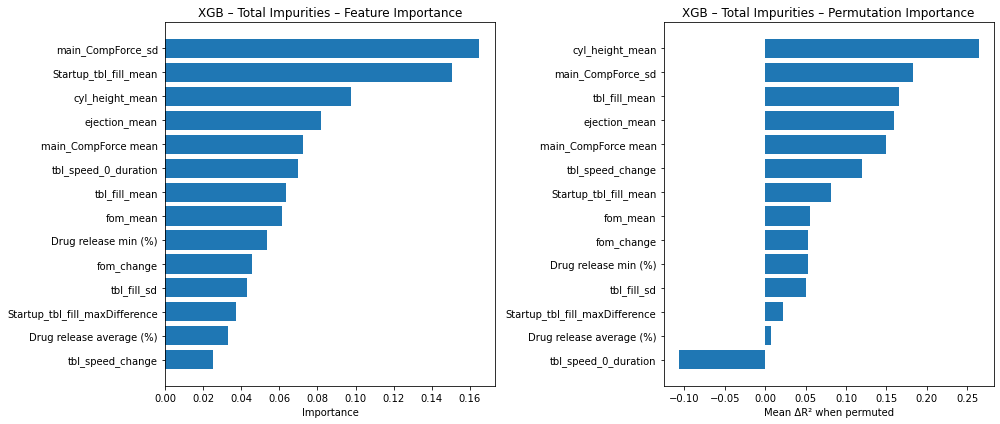


SHAP beeswarm for RF – Total Impurities


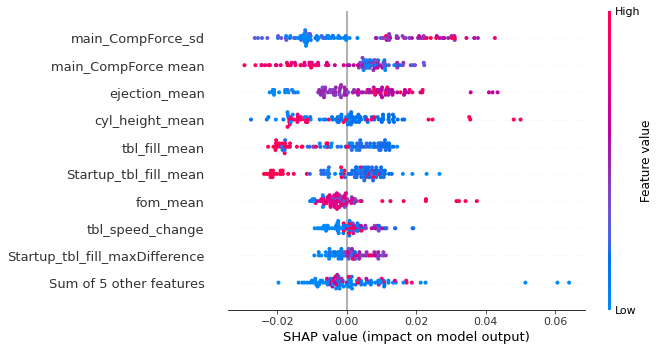

ntree_limit is deprecated, use `iteration_range` or model slicing instead.



SHAP beeswarm for XGB – Total Impurities


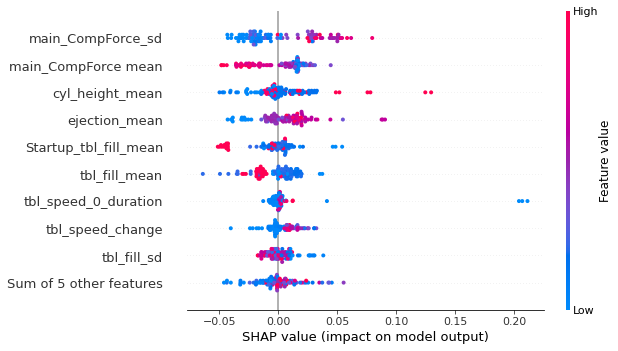

In [52]:
#Total Impurities Modeling
y_ti = process[target_ti].copy()

X_train_ti, X_test_ti, y_train_ti, y_test_ti = train_test_split(
    X, y_ti, test_size=0.2, random_state=42)

rf_ti, xgb_ti = train_models(
    X_train_ti, X_test_ti, y_train_ti, y_test_ti,
    label="Total Impurities")

plot_global_importance(rf_ti, X_test_ti, y_test_ti, features, "RF – Total Impurities")
plot_global_importance(xgb_ti, X_test_ti, y_test_ti, features, "XGB – Total Impurities")

shap_beeswarm(rf_ti, X_test_ti, "RF – Total Impurities")
shap_beeswarm(xgb_ti, X_test_ti, "XGB – Total Impurities")

Based on the local and global interpretation of the best performing models, the selected features for predicting total waste are: cyl_height_mean, tbl_fill_mean, fom_change, tbl_speed_change, Startup_tbl_fill_mean, tbl_speed_0_duration, fom_mean, main_CompForce mean, main_CompForce_sd, and Startup_tbl_fill_maxDifference.

The selected features for predicting total impurities are: main_CompForce_sd, cyl_height_mean, tbl_fill_mean, Startup_tbl_fill_mean, ejection_mean, main_CompForce mean, fom_mean, tbl_speed_change.

In [53]:
#All screened features
screened_features = ['cyl_height_mean', 'tbl_fill_mean', 'fom_change', 'tbl_speed_change', 'Startup_tbl_fill_mean',
'tbl_speed_0_duration', 'fom_mean', 'main_CompForce mean', 'main_CompForce_sd', 'Startup_tbl_fill_maxDifference',
'ejection_mean', 'fom_mean']

In [54]:
#New features that have been added to the original 7 
added_features = ['fom_change', 'tbl_speed_change', 'tbl_speed_0_duration', 'fom_mean', 'fom_mean']